In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy.signal import periodogram
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from statsmodels.graphics.tsaplots import plot_pacf

In [149]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

In [150]:
WINDOW_SIZE = 14 
TARGET_LABEL = "min_temp_F"
rain_cols = ["precipitation_inch", "snow_inch", "snow_depth_inch"]
temp_cols = ["max_temp_F", "min_temp_F"]
weather_cols = rain_cols + temp_cols
weather_feature_dict = {
    "none": [],
    "all": weather_cols,
    "rain": rain_cols,
    "temp": temp_cols
}

## Hyper parameters

In [ ]:
TRAIN_SAMPLE_STEP_SIZE = 1 # The number of samples between the start of two consecutive windows when creating the training set
USE_MONTH_FEATURE = True
USE_SEASONAL_FEATURES = False
VAL_SIZE = 0.2  # fraction of data to use for validation
NUM_LAGS = 4
USE_WEATHER_FEATURES = "all" # "none", "all", "rain", "temp"
T_IMPUTATION_VALUE = 0.0 # Value to use when imputing trace amounts of precipitation
FOURIER_ORDER = 1 # The order of the fourier series when creating seasonal features
VAL_SAMPLE_STEP_SIZE = 1 # The number of samples between the start of two consecutive windows when creating the validation set
MODEL_TYPE = "xgb" # "linear", "xgb"

In [152]:
def no_target(features):
    return [feature for feature in features if feature != TARGET_LABEL]


WEATHER_FEATURES = weather_feature_dict[USE_WEATHER_FEATURES]
DROPPED_FEATURES = ['date', TARGET_LABEL] # Features to drop from the training set
DROPPED_FEATURES

['date', 'min_temp_F']

In [153]:
def load_data():
    full_train_df = pd.read_csv("data/train.csv")
    test_df = pd.read_csv("data/test.csv")
    return full_train_df, test_df

full_train_df, test_df = load_data()
full_train_df.head()

,Date,Maximum Temperature degrees (F),Minimum Temperature degrees (F),Precipitation (inches),Snow (inches),Snow Depth (inches)
0,2010-01-01,6.0,-9.0,T,T,9.00
1,2010-01-02,1.0,-15.0,0.00,0.00,9.00
2,2010-01-03,7.0,-14.0,0.00,0.00,9.00
3,2010-01-04,7.0,-10.0,0.00,0.00,9.00
4,2010-01-05,10.0,-9.0,0.00,0.00,9.00


In [154]:
def clean_features(df, test=False, use_month_feature=USE_MONTH_FEATURE, t_imputation_value=T_IMPUTATION_VALUE):
    df = df.copy()
    df.columns = ["date", "max_temp_F", "min_temp_F", "precipitation_inch", "snow_inch", "snow_depth_inch"]
    df['date'] = pd.to_datetime(df['date'])
    if test: # test_df
        all_dates = pd.date_range(start=df['date'].min(), end=df['date'].max() + pd.Timedelta(days=1), freq='D')
        df = df.set_index('date').reindex(all_dates).reset_index().rename(columns={'index': 'date'})

    if use_month_feature:
        df['month'] = (df['date'].dt.dayofyear - 1) / 365 * 12

    for col in rain_cols:
        for i in range(len(df)):
            if df[col].iloc[i] == "T":
                df.loc[i, col] = t_imputation_value
        df[col] = df[col].astype(float)
    
    return df


full_train_df = clean_features(full_train_df)
test_df = clean_features(test_df, test=True)
test_df.to_csv("data/test_cleaned.csv", index=False)
full_train_df.head()

,date,max_temp_F,min_temp_F,precipitation_inch,snow_inch,snow_depth_inch,month
0,2010-01-01,6.0,-9.0,0.0,0.0,9.0,0.000000
1,2010-01-02,1.0,-15.0,0.0,0.0,9.0,0.032877
2,2010-01-03,7.0,-14.0,0.0,0.0,9.0,0.065753
3,2010-01-04,7.0,-10.0,0.0,0.0,9.0,0.098630
4,2010-01-05,10.0,-9.0,0.0,0.0,9.0,0.131507


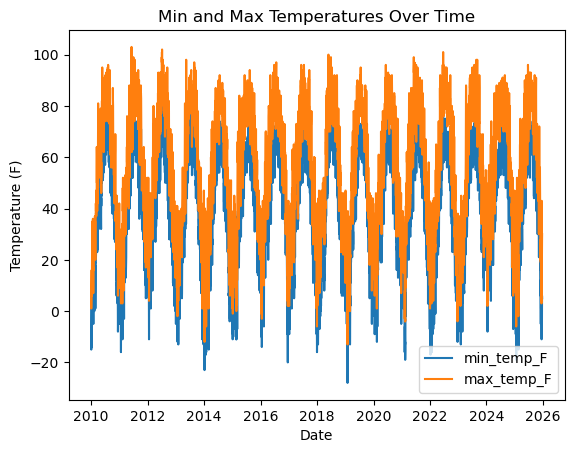

In [155]:
fig, ax = plt.subplots()
ax.plot('date', 'min_temp_F', data=full_train_df)
ax.plot('date', 'max_temp_F', data=full_train_df)
ax.set_title('Min and Max Temperatures Over Time');
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (F)')
ax.legend();

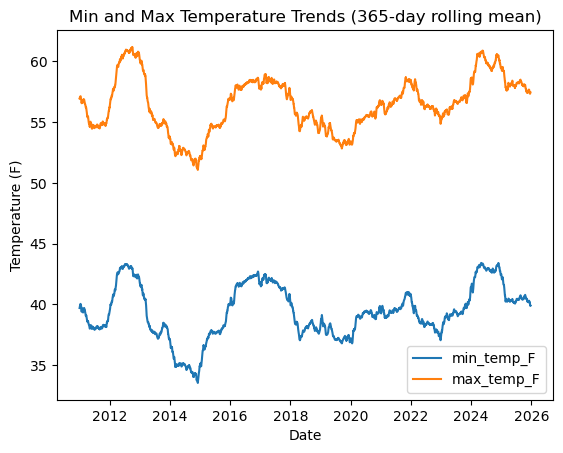

In [156]:
smoothed_temp = full_train_df[["date", "min_temp_F", "max_temp_F"]].copy()
for col in ['min_temp_F', 'max_temp_F']:
    smoothed_temp[col] = smoothed_temp[col].rolling(window=365).mean()

fig, ax = plt.subplots()
ax.plot('date', 'min_temp_F', data=smoothed_temp)
ax.plot('date', 'max_temp_F', data=smoothed_temp)
ax.set_title('Min and Max Temperature Trends (365-day rolling mean)');
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (F)')
ax.legend();

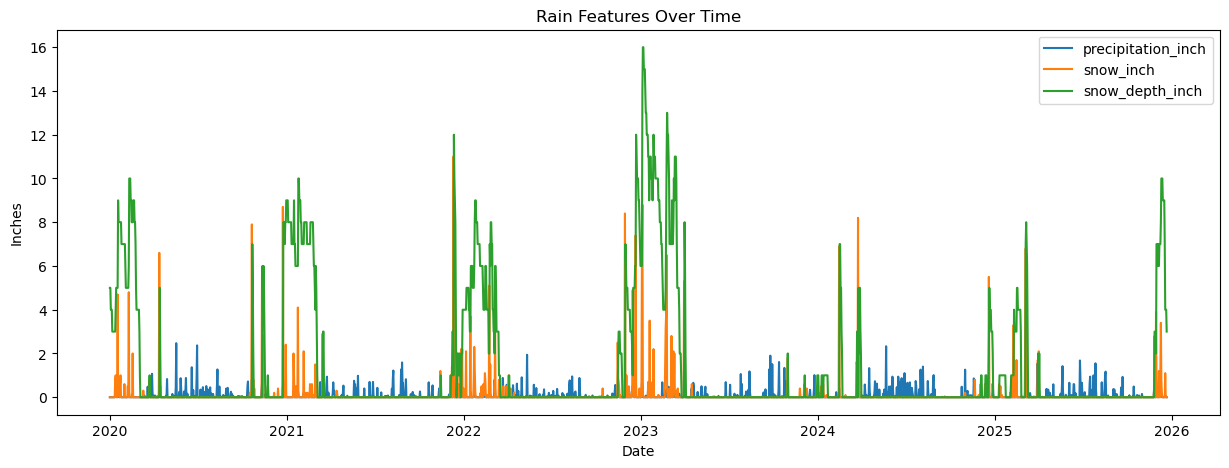

In [157]:
date_range = ("2020-01-01", "2025-12-31")
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)
for feature in rain_cols:
    ax.plot('date', feature, data=full_train_df[(full_train_df['date'] >= date_range[0]) & (full_train_df['date'] <= date_range[1])], label=feature)
ax.set_title('Rain Features Over Time');
ax.set_xlabel('Date')
ax.set_ylabel('Inches')
ax.legend()

In [158]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                       for i in range(X.shape[1])]
    return vif_data

vif_df = calculate_vif(full_train_df[no_target(weather_cols)])
vif_df.sort_values(by="VIF", ascending=False)

,Feature,VIF
0,precipitation_inch,1.186583
3,max_temp_F,1.153406
1,snow_inch,1.121378
2,snow_depth_inch,1.087630


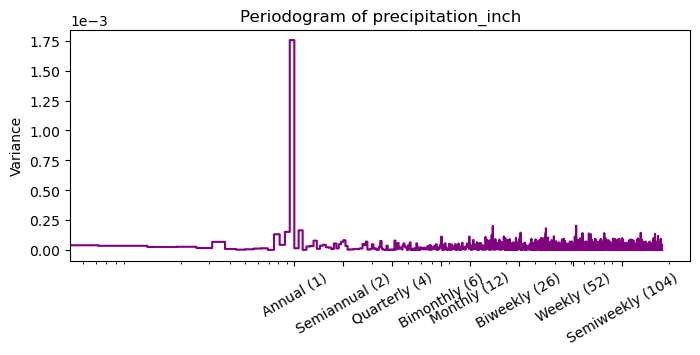

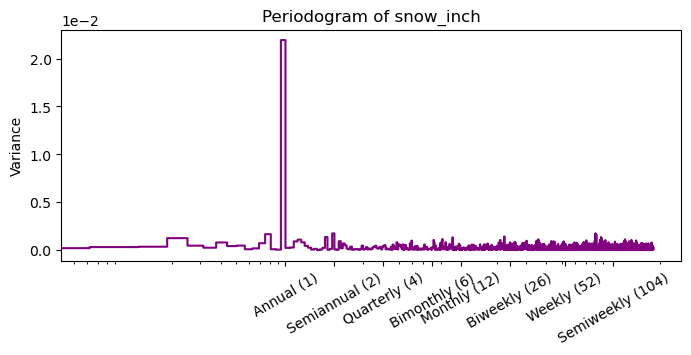

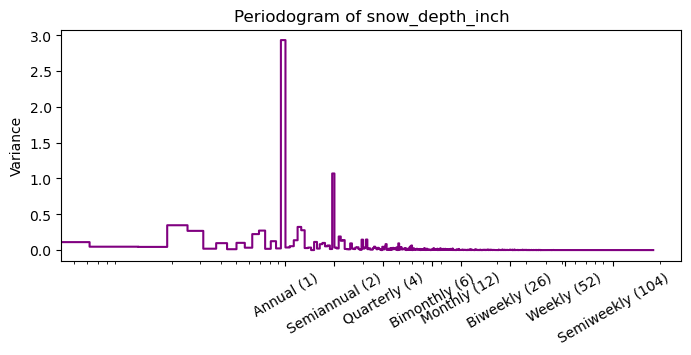

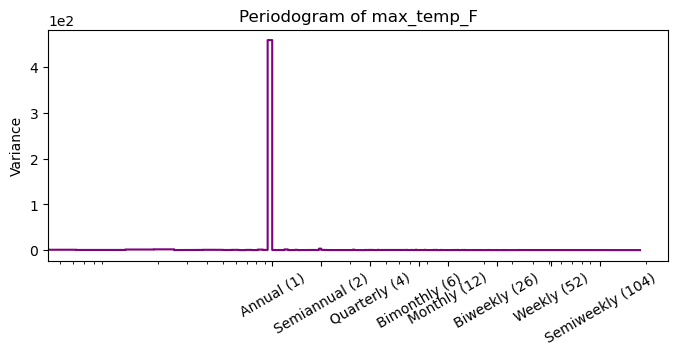

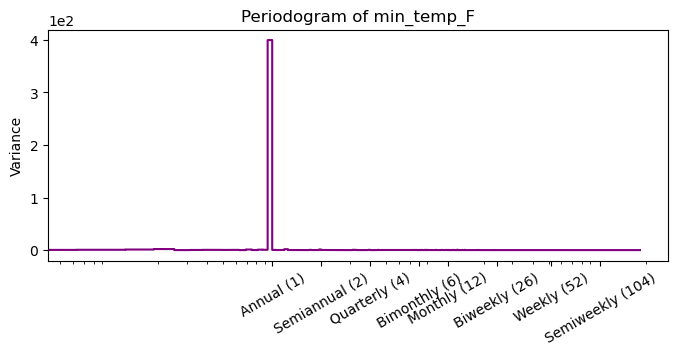

In [159]:
def plot_periodogram(ts, detrend='linear', label='', ax=None):
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        fig, ax = plt.subplots()
    fig.set_size_inches(8, 3)
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 8, 12, 24, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title(f"Periodogram of {label}")
    return ax

for col in weather_cols:
    plot_periodogram(full_train_df[col], label=col)

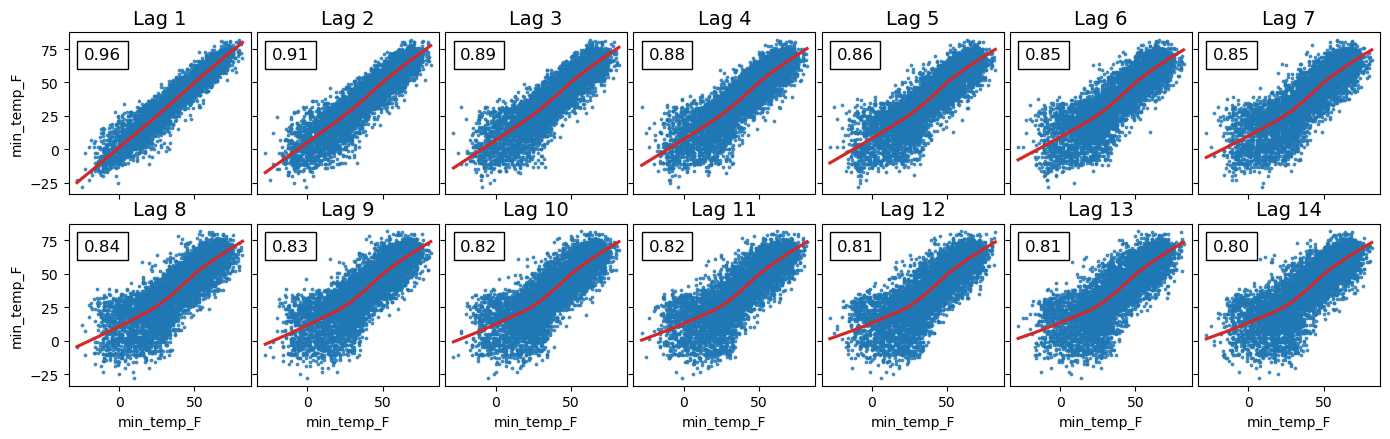

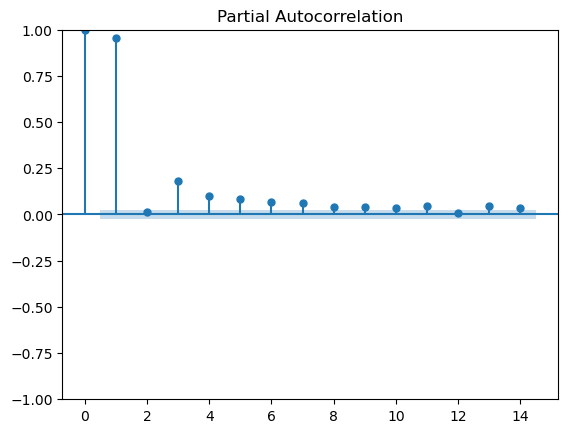

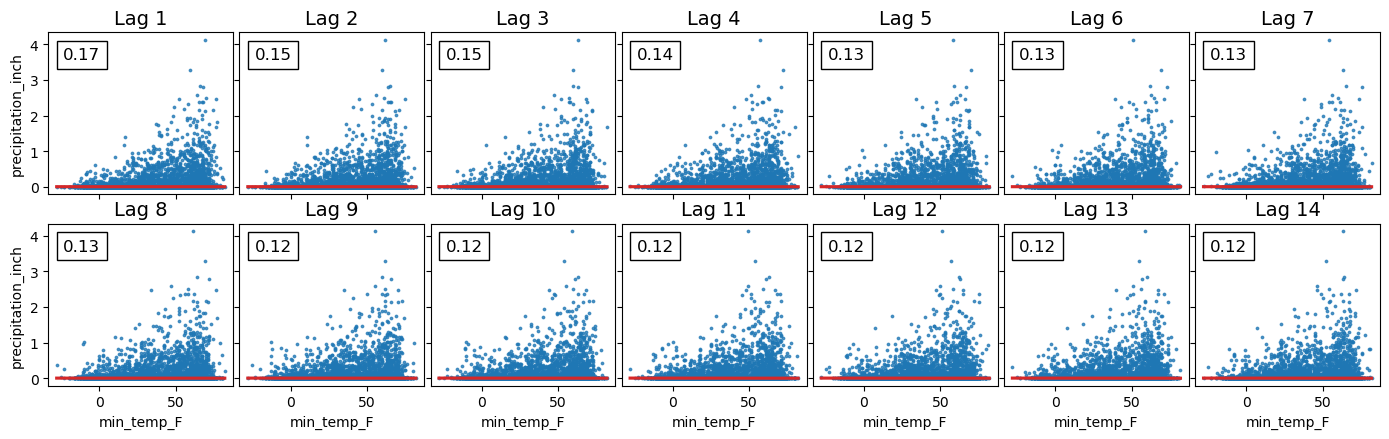

In [160]:
def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=4, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig

plot_lags(full_train_df[TARGET_LABEL], lags=WINDOW_SIZE, nrows=2);
plot_pacf(full_train_df[TARGET_LABEL], lags=WINDOW_SIZE);
plot_lags(full_train_df[TARGET_LABEL], full_train_df['precipitation_inch'], lags=WINDOW_SIZE, nrows=2);

In [161]:
def add_seasonal_features(df, order=FOURIER_ORDER):
    fourier = CalendarFourier(freq="YE", order=order)
    dp = DeterministicProcess(
        index=df['date'],
        constant=False,               # dummy feature for bias (y-intercept)
        order=1,                     # trend (order 1 means linear)
        additional_terms=[fourier],  # annual seasonality (fourier)
        drop=True,                   # drop terms to avoid collinearity
    )

    time_features = dp.in_sample().reset_index()  # create features for dates in tunnel.index
    df = df.merge(time_features, on="date")
    return df


if USE_SEASONAL_FEATURES:
    full_train_df = add_seasonal_features(full_train_df)
    test_df = add_seasonal_features(test_df)
    full_train_df.head()

In [162]:
def add_lag_features(df, lags, target_cols):
    for target_col in target_cols:
        for lag in range(1, lags + 1):
            df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    df = df.drop(no_target(weather_cols), axis=1)
    return df

full_train_df = add_lag_features(full_train_df, NUM_LAGS, WEATHER_FEATURES)
test_df = add_lag_features(test_df, NUM_LAGS, WEATHER_FEATURES)
full_train_df.head()

,date,min_temp_F,month,precipitation_inch_lag_1,precipitation_inch_lag_2,precipitation_inch_lag_3,precipitation_inch_lag_4,snow_inch_lag_1,snow_inch_lag_2,snow_inch_lag_3,snow_inch_lag_4,snow_depth_inch_lag_1,snow_depth_inch_lag_2,snow_depth_inch_lag_3,snow_depth_inch_lag_4,max_temp_F_lag_1,max_temp_F_lag_2,max_temp_F_lag_3,max_temp_F_lag_4,min_temp_F_lag_1,min_temp_F_lag_2,min_temp_F_lag_3,min_temp_F_lag_4
0,2010-01-01,-9.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-02,-15.0,0.032877,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,9.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN,-9.0,NaN,NaN,NaN
2,2010-01-03,-14.0,0.065753,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,9.0,9.0,NaN,NaN,1.0,6.0,NaN,NaN,-15.0,-9.0,NaN,NaN
3,2010-01-04,-10.0,0.098630,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,9.0,9.0,9.0,NaN,7.0,1.0,6.0,NaN,-14.0,-15.0,-9.0,NaN
4,2010-01-05,-9.0,0.131507,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,9.0,9.0,7.0,7.0,1.0,6.0,-10.0,-14.0,-15.0,-9.0


In [163]:
def train_val_split(full_train_df, val_size=VAL_SIZE):
    val_size_days = int(len(full_train_df) * val_size)
    train_df = full_train_df.iloc[:-val_size_days].copy()
    val_df = full_train_df.tail(val_size_days).copy()
    return train_df, val_df

train_df, val_df = train_val_split(full_train_df)
print(f"Train set interval: {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Validation set interval: {val_df['date'].min().date()} to {val_df['date'].max().date()}")

Train set interval: 2010-01-01 to 2022-10-12
Validation set interval: 2022-10-13 to 2025-12-21


In [ ]:
def create_dataset(df, step_size, similar_to_test_set=False):
    df = df.copy()
    if similar_to_test_set:
        df = df[
            (
                (df['date'].dt.month > 4) | 
                ((df['date'].dt.month == 4) & (df['date'].dt.day >= 23))
            ) & 
            (
                (df['date'].dt.month < 10) | 
                ((df['date'].dt.month == 10) & (df['date'].dt.day <= 3))
            )
        ]
    df = df.iloc[::step_size]
    df = df.dropna()
    X = df.drop(DROPPED_FEATURES, axis=1)
    y = df[TARGET_LABEL]
    return X, y

X_train, y_train = create_dataset(train_df, step_size=TRAIN_SAMPLE_STEP_SIZE)
X_val, y_val = create_dataset(val_df, step_size=VAL_SAMPLE_STEP_SIZE, similar_to_test_set=True)
X_train.head()

,month,precipitation_inch_lag_1,precipitation_inch_lag_2,precipitation_inch_lag_3,precipitation_inch_lag_4,snow_inch_lag_1,snow_inch_lag_2,snow_inch_lag_3,snow_inch_lag_4,snow_depth_inch_lag_1,snow_depth_inch_lag_2,snow_depth_inch_lag_3,snow_depth_inch_lag_4,max_temp_F_lag_1,max_temp_F_lag_2,max_temp_F_lag_3,max_temp_F_lag_4,min_temp_F_lag_1,min_temp_F_lag_2,min_temp_F_lag_3,min_temp_F_lag_4
4,0.131507,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,9.0,9.0,7.0,7.0,1.0,6.0,-10.0,-14.0,-15.0,-9.0
5,0.164384,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,9.0,9.0,10.0,7.0,7.0,1.0,-9.0,-10.0,-14.0,-15.0
6,0.197260,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,9.0,9.0,9.0,9.0,16.0,10.0,7.0,7.0,-4.0,-9.0,-10.0,-14.0
7,0.230137,0.06,0.00,0.0,0.0,2.2,0.0,0.0,0.0,11.0,9.0,9.0,9.0,16.0,16.0,10.0,7.0,4.0,-4.0,-9.0,-10.0
8,0.263014,0.00,0.06,0.0,0.0,0.0,2.2,0.0,0.0,11.0,11.0,9.0,9.0,8.0,16.0,16.0,10.0,-6.0,4.0,-4.0,-9.0


In [165]:
def fit_model(X_train, y_train, model_type):
    if model_type == 'linear':
        model = LinearRegression().fit(X_train, y_train)
    elif model_type == 'xgb':
        model = XGBRegressor().fit(X_train, y_train)
    else:
        raise ValueError("Unsupported model_type. Choose 'linear' or 'xgboost'.")
    return model

model = fit_model(X_train, y_train, model_type=MODEL_TYPE)

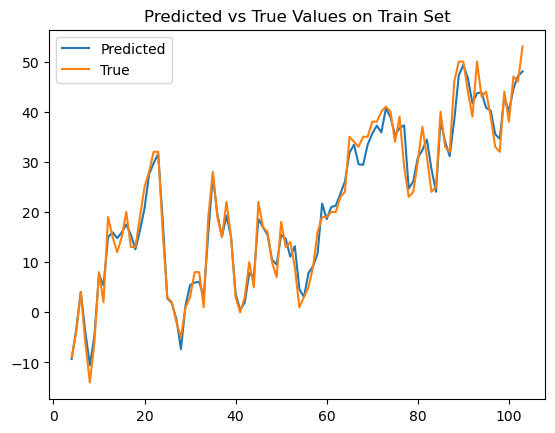

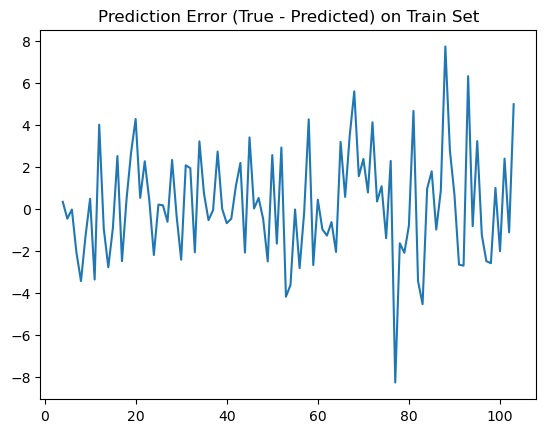

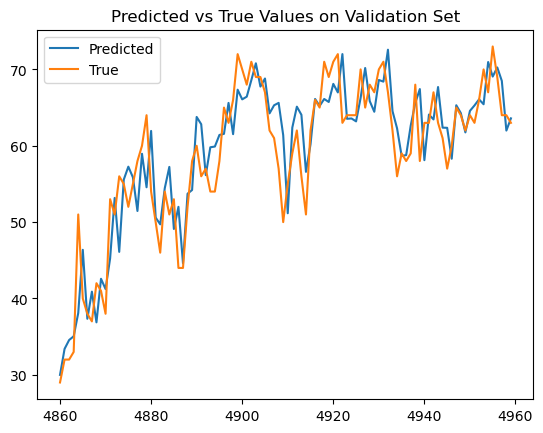

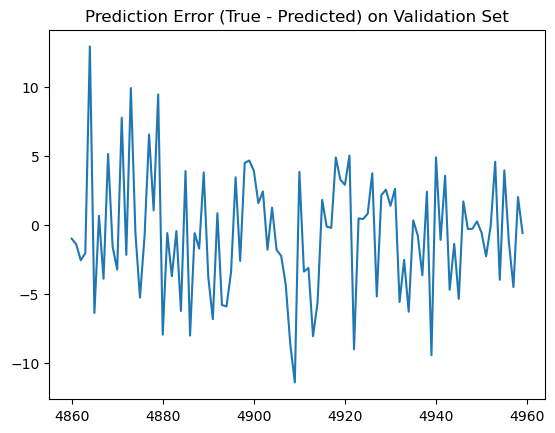

In [166]:
def predict(model, X, y):
    y_pred = pd.Series(model.predict(X), index=X.index)
    y_true = y
    y_diff = y_true - y_pred
    return y_pred, y_true, y_diff

def plot_prediction(model, X, y, dataset_name, length):
    y_pred, y_true, y_diff = predict(model, X, y)
    y_pred[:length].plot(label='Predicted')
    y_true[:length].plot(label='True')
    plt.title(f'Predicted vs True Values on {dataset_name} Set')
    plt.legend()
    plt.show()
    y_diff[:length].plot(title=f'Prediction Error (True - Predicted) on {dataset_name} Set')
    plt.show()


plot_prediction(model, X_train, y_train, dataset_name='Train', length=100)
plot_prediction(model, X_val, y_val, dataset_name='Validation', length=100)

In [167]:
def validation_mae(model, X, y):
    y_pred, y_true, y_diff = predict(model, X, y)
    mask = y_true != 0
    y_pred, y_true, y_diff = y_pred[mask], y_true[mask], y_diff[mask]
    mae = np.mean(np.abs(y_diff / y_true))
    return mae.item()

mae = validation_mae(model, X_val, y_val)
print('mae:', mae)

mae: 0.05398101727668419


In [ ]:
import itertools

def train(use_month_feature, t_imputation_value, use_seasonal_features, fourier_order, num_lags, weather_features, train_sample_step_size):
    full_train_df, _ = load_data()
    full_train_df = clean_features(full_train_df, test=False, use_month_feature=use_month_feature, t_imputation_value=t_imputation_value)
    if use_seasonal_features:
        full_train_df = add_seasonal_features(full_train_df, order=fourier_order)
    full_train_df = add_lag_features(full_train_df, num_lags, weather_features)

    train_df, val_df = train_val_split(full_train_df, VAL_SIZE)

    X_train, y_train = create_dataset(train_df, step_size=train_sample_step_size)
    if X_train.empty:
        return float('inf')
    X_val, y_val = create_dataset(val_df, step_size=VAL_SAMPLE_STEP_SIZE, similar_to_test_set=True)

    model = fit_model(X_train, y_train, model_type=MODEL_TYPE)
    mae = validation_mae(model, X_val, y_val)
    return mae

def hyperparameter_search(n_iter=None):
    param_grid = {
        'use_month_feature': [True, False],
        't_imputation_value': [0.0, 0.001, 0.01, 0.1],
        'use_seasonal_features': [True, False],
        'fourier_order': [1, 2, 3],
        'num_lags': [4, 8, 14],
        'weather_features': ["none", "rain", "temp", "all"],
        'train_sample_step_size': [1, WINDOW_SIZE]
    }
    print('Total param combinations:', np.prod([len(v) for v in param_grid.values()]))
    param_combinations = list(itertools.product(*param_grid.values()))
    if n_iter is None:
        n_iter = len(param_combinations)
    else:
        n_iter = min(n_iter, len(param_combinations))
    best_mae = float('inf')
    best_params = None
    maes = []
    for i in range(n_iter):
        params = param_combinations[i]
        param_dict = dict(zip(param_grid.keys(), params))
        print(f"Testing combination {i + 1}/{n_iter}", end="\r")
        mae = train(
            use_month_feature=param_dict['use_month_feature'],
            t_imputation_value=param_dict['t_imputation_value'],
            use_seasonal_features=param_dict['use_seasonal_features'],
            fourier_order=param_dict['fourier_order'],
            num_lags=param_dict['num_lags'],
            weather_features=weather_feature_dict[param_dict['weather_features']],
            train_sample_step_size=param_dict['train_sample_step_size']
        )
        maes.append(mae)
        if mae < best_mae:
            best_mae = mae
            best_params = param_dict
    print()
    print(f"Best MAE: {best_mae} with params: {best_params}")
    return best_mae, best_params

# hyperparameter_search();

### Grid search results:  
```
{
    'use_month_feature': True,  
    't_imputation_value': 0.0,  
    'use_seasonal_features': False,  
    'num_lags': 4,  
    'weather_features': 'all',  
    'train_sample_step_size': 1
}
```

In [169]:
def make_submission(train_df, test_df):
    X_train, y_train = create_dataset(train_df, step_size=TRAIN_SAMPLE_STEP_SIZE)
    model = fit_model(X_train, y_train, model_type=MODEL_TYPE)
    X_test = test_df[test_df[TARGET_LABEL].isna()].drop(DROPPED_FEATURES, axis=1)
    y_pred = model.predict(X_test)
    result_df = pd.DataFrame({
        'ID': np.arange(len(y_pred)),
        'Minimum Temperature degrees (F)': y_pred
    })
    return result_df

submission = make_submission(full_train_df, test_df)
submission.to_csv(f"submission_{MODEL_TYPE}.csv", index=False)